# Upscaling: Analytic Thin-Sheet Impedance

This notebook demonstrates electromagnetic upscaling for thin conducting / permeable sheets
and cylindrical casings using analytic impedance models.

Functions are imported from `thin_sheet.py`.  The workflow covers:

1. Forward impedance models (sheet, casing, slab, cylinder)
2. Conductivity-only upscaling inversion for a thin sheet
3. Joint σ + μ upscaling inversion for a thin sheet
4. Debye model fitting to effective properties
5. Direct Debye fit to impedance
6. Conductivity-only upscaling inversion for a solid cylinder
7. Joint σ + μ upscaling inversion for a solid cylinder


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import ipywidgets
from scipy.constants import mu_0

from thin_sheet import (
    gamma, wave_impedance,
    impedance_sheet, impedance_sheet_deriv_sigma, impedance_sheet_deriv_mu,
    impedance_cyl_symmetric, impedance_hollow_cyl,
    input_impedance_slab_symmetric, impedance_slab_dsigma, impedance_slab_dmu,
    impedance_solid_cyl, impedance_solid_cyl_dsigma, impedance_solid_cyl_dmu,
    impedance_open_cyl,
    loss_sheet, loss_cylinder,
    solve_sigma_eff_one_freq, invert_sigma_eff_vs_freq,
    solve_sigma_mu_eff_one_freq_sheet, invert_sigma_mu_eff_vs_freq_sheet,
    solve_sigma_eff_one_freq_solid_cyl, invert_sigma_eff_vs_freq_solid_cyl,
    solve_sigma_mu_eff_one_freq_solid_cyl, invert_sigma_mu_eff_vs_freq_solid_cyl,
    sigma_debye, debye_one, debye_basis,
    fit_debye_to_sigma,
    predict_Z_sheet_debye, fit_debye_sigma_mu_to_impedance,
    predict_Z_sheet_debye_decomp, eval_sigma_mu_from_p,
    fit_debye_decomp_sigma_mu_to_impedance,
)

## Parameters

In [3]:
# Sheet / casing material
mu_r = 100.0
mu = mu_0 * mu_r
sigma = 5e6          # S/m
eps = 0.0

# Geometry
b = 0.05             # outer radius [m]
t = 0.01             # wall thickness [m]
a = b - t            # inner radius [m]

# Background medium
mu1 = mu_0
sigma1 = 1e-6
mu2 = mu
sigma2 = sigma
eps1 = eps2 = 0.0

# Frequency sweep
frequencies = np.logspace(1, 4.5, 5000)  # Hz
omegas = 2 * np.pi * frequencies

## 1. Forward Impedance Models

Compare thin-sheet, cylindrical, open-bore, and solid-cylinder impedances.

In [4]:
Z_sheet  = impedance_sheet(omegas, b - a, mu2, sigma2)
Z_casing = impedance_cyl_symmetric(omegas, a, b, mu1, sigma1, mu2, sigma2)
Z_open   = impedance_open_cyl(omegas, a, b, mu2, sigma2)
Z_solid  = impedance_solid_cyl(omegas, b, mu2, sigma2)

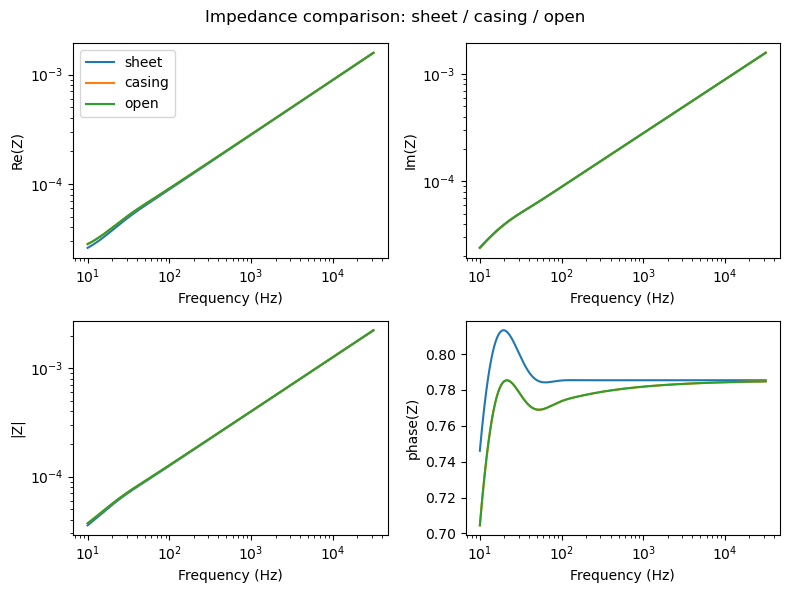

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

for ai, comp in zip(ax[0, :], ['real', 'imag']):
    ai.loglog(frequencies, getattr(Z_sheet,  comp), label='sheet')
    ai.loglog(frequencies, getattr(Z_casing, comp), label='casing')
    ai.loglog(frequencies, getattr(Z_open,   comp), label='open')

ax[1, 0].loglog(frequencies, np.abs(Z_sheet))
ax[1, 0].loglog(frequencies, np.abs(Z_casing))
ax[1, 0].loglog(frequencies, np.abs(Z_open))
ax[1, 0].set_ylabel('|Z|')

ax[1, 1].semilogx(frequencies, np.angle(Z_sheet))
ax[1, 1].semilogx(frequencies, np.angle(Z_casing))
ax[1, 1].semilogx(frequencies, np.angle(Z_open))
ax[1, 1].set_ylabel('phase(Z)')

ax[0, 0].set_ylabel('Re(Z)'); ax[0, 1].set_ylabel('Im(Z)')
ax[0, 0].legend()
for a_ in ax.flat: a_.set_xlabel('Frequency (Hz)')
fig.suptitle('Impedance comparison: sheet / casing / open')
plt.tight_layout()

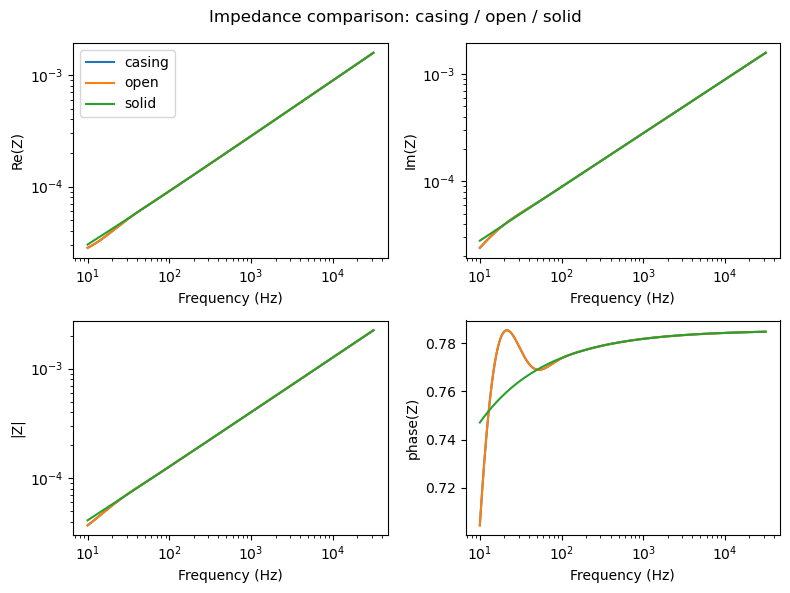

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

for ai, comp in zip(ax[0, :], ['real', 'imag']):
    ai.loglog(frequencies, getattr(Z_casing, comp), label='casing')
    ai.loglog(frequencies, getattr(Z_open,   comp), label='open')
    ai.loglog(frequencies, getattr(Z_solid,  comp), label='solid')

ax[1, 0].loglog(frequencies, np.abs(Z_casing))
ax[1, 0].loglog(frequencies, np.abs(Z_open))
ax[1, 0].loglog(frequencies, np.abs(Z_solid))
ax[1, 0].set_ylabel('|Z|')

ax[1, 1].semilogx(frequencies, np.angle(Z_casing))
ax[1, 1].semilogx(frequencies, np.angle(Z_open))
ax[1, 1].semilogx(frequencies, np.angle(Z_solid))
ax[1, 1].set_ylabel('phase(Z)')

ax[0, 0].set_ylabel('Re(Z)'); ax[0, 1].set_ylabel('Im(Z)')
ax[0, 0].legend()
for a_ in ax.flat: a_.set_xlabel('Frequency (Hz)')
fig.suptitle('Impedance comparison: casing / open / solid')
plt.tight_layout()

## 2. Conductivity-Only Thin-Sheet Upscaling

Invert the thin-sheet impedance at every frequency to find an effective
conductivity σ_eff such that a sheet of thickness `t_eff` reproduces the same
impedance as the true thin sheet.

In [7]:
# True sheet parameters
sigma_sheet = 1e6    # S/m
t_sheet     = 0.01   # m
mur_sheet   = 1
mu_sheet    = mur_sheet * mu_0

z_thin_sheet = impedance_sheet(omegas, t_sheet, mu_sheet, sigma_sheet)

# Effective (upscaled) sheet thickness
t_eff = 0.0134

In [8]:
# Derivative test at one frequency
ind = 0
solve_sigma_eff_one_freq(omegas[ind], z_thin_sheet[ind], t_eff=0.1, mu=mu_0, test=True, sigma0=sigma_sheet)

==================== check_derivative ====================
iter    h         |ft-f0|   |ft-f0-h*J0*dx|  Order
---------------------------------------------------------
 0   1.00e-01    1.822e-12     3.376e-19      nan
 1   1.00e-02    1.822e-13     4.907e-21      1.838
 2   1.00e-03    1.822e-14     7.826e-21      -0.203
 3   1.00e-04    1.822e-15     6.310e-22      1.094
 4   1.00e-05    1.822e-16     5.742e-21      -0.959
 5   1.00e-06    1.821e-17     2.802e-21      0.312
 6   1.00e-07    1.821e-18     5.216e-21      -0.270
========================= PASS! =========================
Go Test Go!



(np.complex128(99957.60546804551+2368.2496421957667j),
 np.complex128(0.00010000013853729164+2.6318934648510294e-07j),
 True,
 '`xtol` termination condition is satisfied.')

In [9]:
sigma_eff, z_eff, ok = invert_sigma_eff_vs_freq(
    omegas, z_thin_sheet, t_eff=t_eff, mu=mu_sheet, sigma_init=sigma_sheet
)

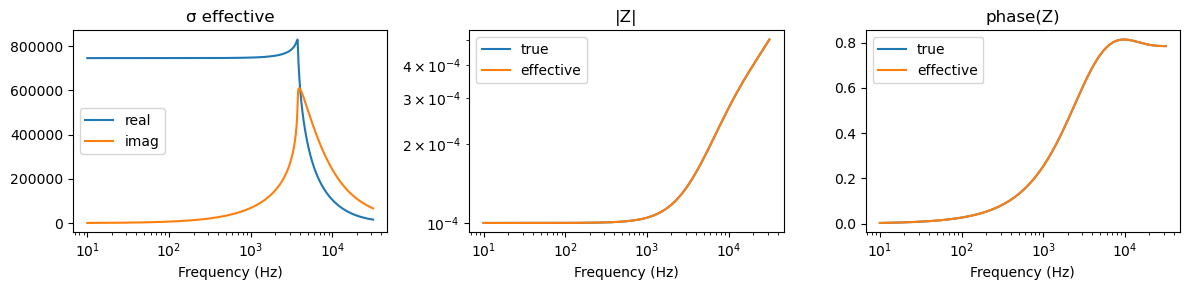

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].semilogx(frequencies[ok], sigma_eff[ok].real, label='real')
ax[0].semilogx(frequencies[ok], sigma_eff[ok].imag, label='imag')
ax[0].set_title('σ effective'); ax[0].legend(); ax[0].set_xlabel('Frequency (Hz)')

ax[1].loglog(frequencies, np.abs(z_thin_sheet), label='true')
ax[1].loglog(frequencies, np.abs(z_eff),        label='effective')
ax[1].set_title('|Z|'); ax[1].legend(); ax[1].set_xlabel('Frequency (Hz)')

ax[2].semilogx(frequencies, np.angle(z_thin_sheet), label='true')
ax[2].semilogx(frequencies, np.angle(z_eff),        label='effective')
ax[2].set_title('phase(Z)'); ax[2].legend(); ax[2].set_xlabel('Frequency (Hz)')

plt.tight_layout()

### 2a. Loss Surface

In [11]:
n_real = n_imag = 500
sr = np.logspace(5.5, 6.5, n_real)
si = np.linspace(-0.1e6, 1e6, n_imag)
SR, SI = np.meshgrid(sr, si, indexing='xy')
loss_landscape = np.zeros((n_real, n_imag, len(omegas)))

for i, omega in enumerate(omegas):
    loss_landscape[:, :, i] = loss_sheet(omega, t_eff, mu_sheet, z_thin_sheet[i], SR, SI)

In [12]:
def plot_loss(index=0):
    fig, ax = plt.subplots(1, 1)
    plt.colorbar(ax.contourf(np.log10(sr), si, np.log10(loss_landscape[:, :, index]), 100))
    ax.set_xlabel('log10(sigma_r)')
    ax.set_ylabel('sigma_i')
    ax.set_title(f'{frequencies[index]:1.2e} Hz')
    ax.plot(np.log10(sigma_sheet), 0, 'wx', label='true')
    ax.plot(np.log10(sigma_sheet * t_sheet / t_eff), 0, 'w+', label='scaled')
    ax.legend()

ipywidgets.interact(
    plot_loss,
    index=ipywidgets.IntSlider(min=0, max=len(omegas) - 1, value=0)
)

interactive(children=(IntSlider(value=0, description='index', max=4999), Output()), _dom_classes=('widget-inte…

<function __main__.plot_loss(index=0)>

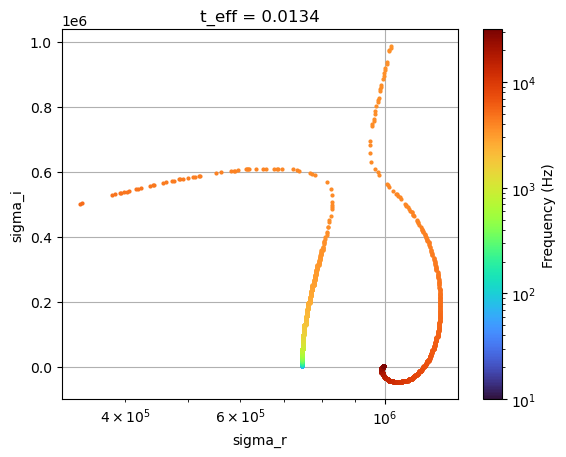

In [13]:
# Plot minimizer locus across frequencies
inds = loss_landscape.copy()
for i in range(len(omegas)):
    thresh = loss_landscape[:, :, i].min()
    inds[:, :, i] = loss_landscape[:, :, i] <= thresh
inds = inds.astype(bool)

fig, ax = plt.subplots(1, 1)
cmap = plt.cm.turbo
norm = mpl.colors.LogNorm(vmin=frequencies.min(), vmax=frequencies.max())
for i, freq in enumerate(frequencies):
    ax.semilogx(SR[inds[:, :, i]], SI[inds[:, :, i]], '.', color=cmap(norm(freq)), ms=4)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax).set_label('Frequency (Hz)')
ax.set_xlabel('sigma_r'); ax.set_ylabel('sigma_i')
ax.set_title(f't_eff = {t_eff}')
ax.grid()

### 2b. Debye Fit to σ_eff

In [14]:
p_hat, res = fit_debye_to_sigma(omegas, sigma_eff)
sigma_inf, delta_sigma, tau = p_hat
print('sigma_inf   =', sigma_inf)
print('delta_sigma =', delta_sigma)
print('tau         =', tau)

sigma_fit = sigma_debye(omegas, *p_hat)

sigma_inf   = 424541.232098874
delta_sigma = 266061.2143562364
tau         = 9.16341182255305e-05


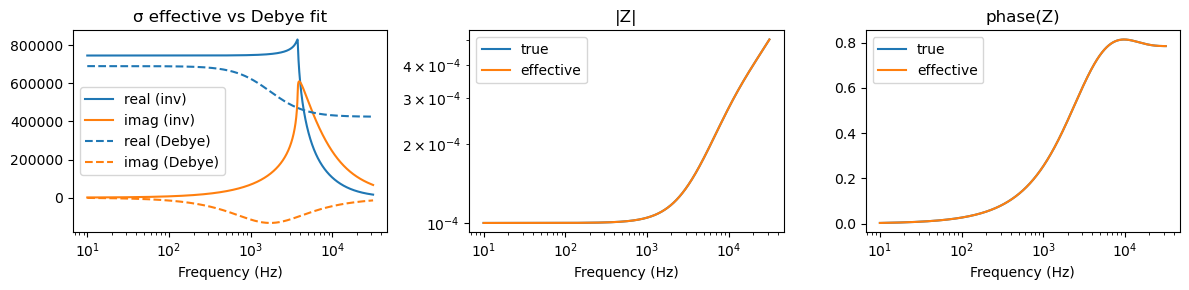

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].semilogx(frequencies, sigma_eff.real, 'C0-',  label='real (inv)')
ax[0].semilogx(frequencies, sigma_eff.imag, 'C1-',  label='imag (inv)')
ax[0].semilogx(frequencies, sigma_fit.real, 'C0--', label='real (Debye)')
ax[0].semilogx(frequencies, sigma_fit.imag, 'C1--', label='imag (Debye)')
ax[0].set_title('σ effective vs Debye fit'); ax[0].legend(); ax[0].set_xlabel('Frequency (Hz)')

ax[1].loglog(frequencies, np.abs(z_thin_sheet), label='true')
ax[1].loglog(frequencies, np.abs(z_eff),        label='effective')
ax[1].set_title('|Z|'); ax[1].legend(); ax[1].set_xlabel('Frequency (Hz)')

ax[2].semilogx(frequencies, np.angle(z_thin_sheet), label='true')
ax[2].semilogx(frequencies, np.angle(z_eff),        label='effective')
ax[2].set_title('phase(Z)'); ax[2].legend(); ax[2].set_xlabel('Frequency (Hz)')

plt.tight_layout()

## 3. Joint σ + μ Thin-Sheet Upscaling

Jointly invert for effective conductivity and permeability at each frequency.

In [16]:
# Derivative test at one frequency
ind = 50
sigma_hat, mu_hat, z_pred, ok_one, msg = solve_sigma_mu_eff_one_freq_sheet(
    omegas[ind], z_thin_sheet[ind],
    t_eff=0.05,
    sigma0=sigma_sheet + 0j,
    mu0=mu_0 + 0j,
    test=True,
    method='trf',
    complex_values=False,
)
print(ok_one, sigma_hat, mu_hat)

==================== check_derivative ====================
iter    h         |ft-f0|   |ft-f0-h*J0*dx|  Order
---------------------------------------------------------
 0   1.00e-01    7.454e-06     5.568e-07      nan
 1   1.00e-02    7.476e-07     5.589e-09      1.998
 2   1.00e-03    7.475e-08     5.588e-11      2.000
 3   1.00e-04    7.475e-09     5.588e-13      2.000
 4   1.00e-05    7.475e-10     5.588e-15      2.000
 5   1.00e-06    7.475e-11     5.587e-17      2.000
 6   1.00e-07    7.475e-12     5.442e-19      2.011
========================= PASS! =========================
You deserve a pat on the back!

True (199999.99997020036+0j) (2.5132741225397425e-07+0j)


In [17]:
sigma_eff2, mu_eff2, z_eff2, ok2 = invert_sigma_mu_eff_vs_freq_sheet(
    omegas, z_thin_sheet, t_eff=0.02,
    sigma_init=sigma_sheet + 0j,
    mu_init=mu_0 + 0j,
    method='trf',
    complex_values=False,
)

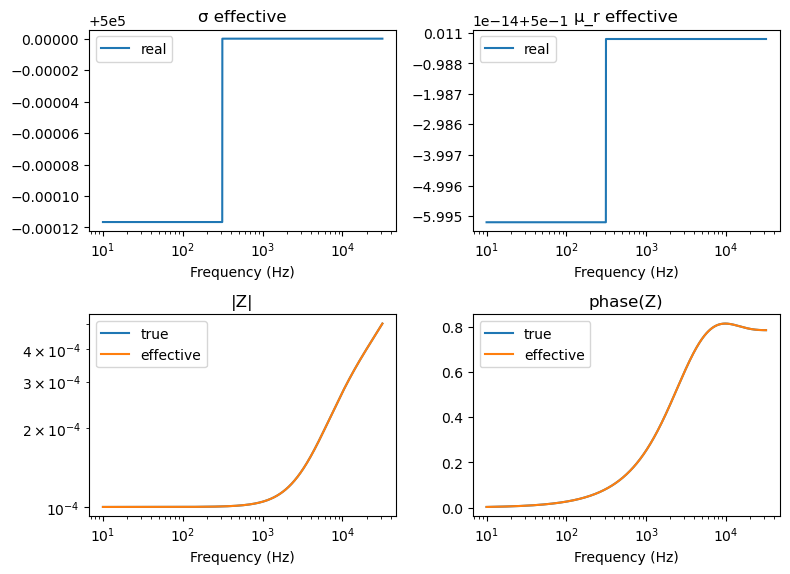

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].semilogx(frequencies, sigma_eff2.real, label='real')
ax[0, 0].set_title('σ effective'); ax[0, 0].legend(); ax[0, 0].set_xlabel('Frequency (Hz)')

ax[0, 1].semilogx(frequencies, mu_eff2.real / mu_0, label='real')
ax[0, 1].set_title('μ_r effective'); ax[0, 1].legend(); ax[0, 1].set_xlabel('Frequency (Hz)')

ax[1, 0].loglog(frequencies, np.abs(z_thin_sheet), label='true')
ax[1, 0].loglog(frequencies, np.abs(z_eff2),       label='effective')
ax[1, 0].set_title('|Z|'); ax[1, 0].legend(); ax[1, 0].set_xlabel('Frequency (Hz)')

ax[1, 1].semilogx(frequencies, np.angle(z_thin_sheet), label='true')
ax[1, 1].semilogx(frequencies, np.angle(z_eff2),       label='effective')
ax[1, 1].set_title('phase(Z)'); ax[1, 1].legend(); ax[1, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout()

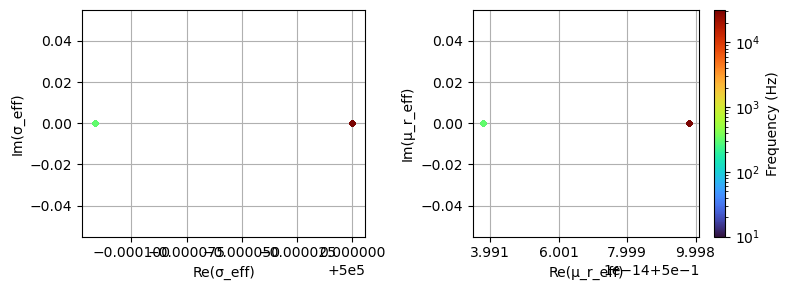

In [19]:
# Cole-Cole plot of σ and μ paths in the complex plane
cmap = plt.cm.turbo
norm = mpl.colors.LogNorm(vmin=frequencies.min(), vmax=frequencies.max())

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
for i, freq in enumerate(frequencies):
    ax[0].plot(sigma_eff2[i].real, sigma_eff2[i].imag, '.', color=cmap(norm(freq)))
    ax[1].plot(mu_eff2[i].real / mu_0, mu_eff2[i].imag / mu_0, '.', color=cmap(norm(freq)))

ax[0].set_xlabel('Re(σ_eff)'); ax[0].set_ylabel('Im(σ_eff)'); ax[0].grid()
ax[1].set_xlabel('Re(μ_r_eff)'); ax[1].set_ylabel('Im(μ_r_eff)'); ax[1].grid()
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax[1]).set_label('Frequency (Hz)')
plt.tight_layout()

### 3a. Debye Fit to σ_eff and μ_eff

In [20]:
p_hat2, res2   = fit_debye_to_sigma(omegas, sigma_eff2)
p_hatmu, resmu = fit_debye_to_sigma(omegas, mu_eff2)

for p, var in zip([p_hat2, p_hatmu], ['sigma', 'mu']):
    x_inf, dx, tau = p
    print(f'\n{var}_inf  = {x_inf:.4g}')
    print(f'd_{var}    = {dx:.4g}')
    print(f'tau       = {tau:.4g}')

sigma_fit2 = sigma_debye(omegas, *p_hat2)
mu_fit2    = sigma_debye(omegas, *p_hatmu)


sigma_inf  = 5e+05
d_sigma    = -6.256e-05
tau       = 0.005631

mu_inf  = 6.283e-07
d_mu    = -7.549e-20
tau       = 0.01592


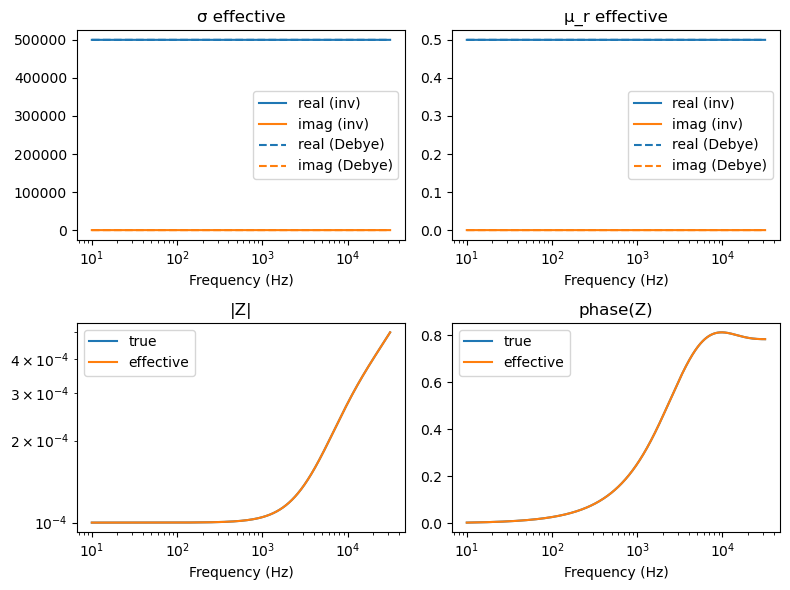

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].semilogx(frequencies, sigma_eff2.real, 'C0-',  label='real (inv)')
ax[0, 0].semilogx(frequencies, sigma_eff2.imag, 'C1-',  label='imag (inv)')
ax[0, 0].semilogx(frequencies, sigma_fit2.real, 'C0--', label='real (Debye)')
ax[0, 0].semilogx(frequencies, sigma_fit2.imag, 'C1--', label='imag (Debye)')
ax[0, 0].set_title('σ effective'); ax[0, 0].legend(); ax[0, 0].set_xlabel('Frequency (Hz)')

ax[0, 1].semilogx(frequencies, mu_eff2.real / mu_0, 'C0-',  label='real (inv)')
ax[0, 1].semilogx(frequencies, mu_eff2.imag / mu_0, 'C1-',  label='imag (inv)')
ax[0, 1].semilogx(frequencies, mu_fit2.real / mu_0, 'C0--', label='real (Debye)')
ax[0, 1].semilogx(frequencies, mu_fit2.imag / mu_0, 'C1--', label='imag (Debye)')
ax[0, 1].set_title('μ_r effective'); ax[0, 1].legend(); ax[0, 1].set_xlabel('Frequency (Hz)')

ax[1, 0].loglog(frequencies, np.abs(z_thin_sheet), label='true')
ax[1, 0].loglog(frequencies, np.abs(z_eff2),       label='effective')
ax[1, 0].set_title('|Z|'); ax[1, 0].legend(); ax[1, 0].set_xlabel('Frequency (Hz)')

ax[1, 1].semilogx(frequencies, np.angle(z_thin_sheet), label='true')
ax[1, 1].semilogx(frequencies, np.angle(z_eff2),       label='effective')
ax[1, 1].set_title('phase(Z)'); ax[1, 1].legend(); ax[1, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout()

## 4. Direct Debye Fit to Impedance

Fit Debye dispersion models for σ(ω) and μ(ω) directly to the impedance data
without first inverting frequency-by-frequency.

In [22]:
t_eff_debye = 0.1

p_hat_d, res_d, ok_d = fit_debye_sigma_mu_to_impedance(
    omega=omegas,
    z_data=z_thin_sheet,
    t_eff=t_eff_debye,
)

sigma_inf_d, d_sigma_d, tau_sigma_d, mu_inf_d, d_mu_d, tau_mu_d = p_hat_d
print(f'success? {ok_d}. cost: {res_d.cost:.3e}')
print('sigma_inf, d_sigma, tau_sigma:', sigma_inf_d, d_sigma_d, tau_sigma_d)
print('mu_inf,    d_mu,    tau_mu:   ', mu_inf_d, d_mu_d, tau_mu_d)

sigma_rec = debye_one(omegas, sigma_inf_d, d_sigma_d, tau_sigma_d)
mu_rec    = debye_one(omegas, mu_inf_d,    d_mu_d,    tau_mu_d)
z_fit_d   = predict_Z_sheet_debye(omegas, t_eff_debye, p_hat_d)

success? False. cost: 3.817e-07
sigma_inf, d_sigma, tau_sigma: 796049.1006782496 -380818.92022797815 0.0002242852962333799
mu_inf,    d_mu,    tau_mu:    9.499727319832989e-07 0.0014254230448066815 0.3363626797150051


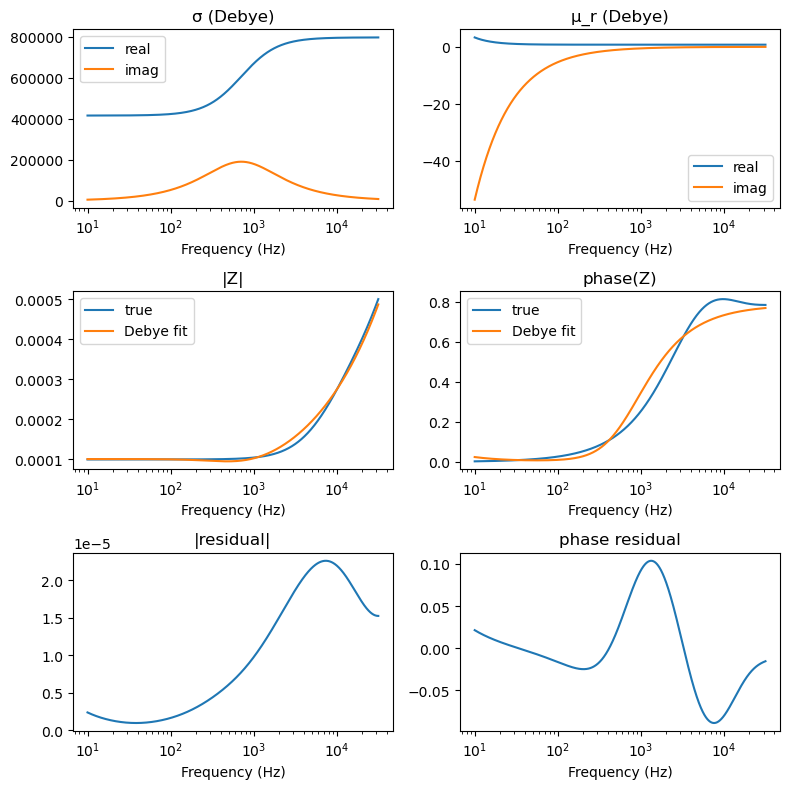

In [23]:
fig, ax = plt.subplots(3, 2, figsize=(8, 8))

ax[0, 0].semilogx(frequencies, sigma_rec.real, label='real')
ax[0, 0].semilogx(frequencies, sigma_rec.imag, label='imag')
ax[0, 0].set_title('σ (Debye)'); ax[0, 0].legend(); ax[0, 0].set_xlabel('Frequency (Hz)')

ax[0, 1].semilogx(frequencies, mu_rec.real / mu_0, label='real')
ax[0, 1].semilogx(frequencies, mu_rec.imag / mu_0, label='imag')
ax[0, 1].set_title('μ_r (Debye)'); ax[0, 1].legend(); ax[0, 1].set_xlabel('Frequency (Hz)')

ax[1, 0].semilogx(frequencies, np.abs(z_thin_sheet), label='true')
ax[1, 0].semilogx(frequencies, np.abs(z_fit_d),      label='Debye fit')
ax[1, 0].set_title('|Z|'); ax[1, 0].legend(); ax[1, 0].set_xlabel('Frequency (Hz)')

ax[1, 1].semilogx(frequencies, np.angle(z_thin_sheet), label='true')
ax[1, 1].semilogx(frequencies, np.angle(z_fit_d),      label='Debye fit')
ax[1, 1].set_title('phase(Z)'); ax[1, 1].legend(); ax[1, 1].set_xlabel('Frequency (Hz)')

ax[2, 0].semilogx(frequencies, np.abs(z_thin_sheet - z_fit_d))
ax[2, 0].set_title('|residual|'); ax[2, 0].set_xlabel('Frequency (Hz)')

ax[2, 1].semilogx(frequencies, np.angle(z_fit_d) - np.angle(z_thin_sheet))
ax[2, 1].set_title('phase residual'); ax[2, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout()

### 4a. Multi-Term Debye Decomposition

In [24]:
K = 15
t_eff_decomp = 0.025
tau = np.logspace(
    np.log10(1 / (2 * np.pi * frequencies.max())),
    np.log10(1 / (2 * np.pi * frequencies.min())),
    K,
)

p_hat_dc, res_dc = fit_debye_decomp_sigma_mu_to_impedance(
    omega=omegas,
    z_data=z_thin_sheet,
    t_eff=t_eff_decomp,
    tau=tau,
)
z_fit_dc = predict_Z_sheet_debye_decomp(omegas, t_eff_decomp, p_hat_dc, tau)
print('final cost:', res_dc.cost, '  success:', res_dc.success)

sigma_fit_dc, mu_fit_dc = eval_sigma_mu_from_p(omegas, p_hat_dc, tau)

final cost: 2.3115941980898985e-08   success: True


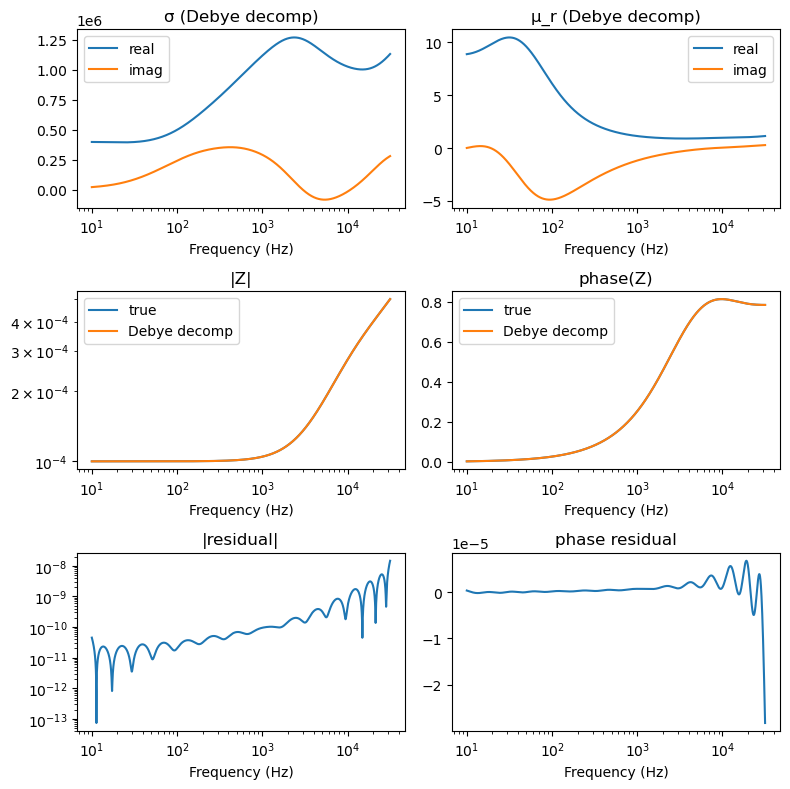

In [25]:
fig, ax = plt.subplots(3, 2, figsize=(8, 8))

ax[0, 0].semilogx(frequencies, sigma_fit_dc.real, label='real')
ax[0, 0].semilogx(frequencies, sigma_fit_dc.imag, label='imag')
ax[0, 0].set_title('σ (Debye decomp)'); ax[0, 0].legend(); ax[0, 0].set_xlabel('Frequency (Hz)')

ax[0, 1].semilogx(frequencies, mu_fit_dc.real / mu_0, label='real')
ax[0, 1].semilogx(frequencies, mu_fit_dc.imag / mu_0, label='imag')
ax[0, 1].set_title('μ_r (Debye decomp)'); ax[0, 1].legend(); ax[0, 1].set_xlabel('Frequency (Hz)')

ax[1, 0].loglog(frequencies, np.abs(z_thin_sheet), label='true')
ax[1, 0].loglog(frequencies, np.abs(z_fit_dc),     label='Debye decomp')
ax[1, 0].set_title('|Z|'); ax[1, 0].legend(); ax[1, 0].set_xlabel('Frequency (Hz)')

ax[1, 1].semilogx(frequencies, np.angle(z_thin_sheet), label='true')
ax[1, 1].semilogx(frequencies, np.angle(z_fit_dc),     label='Debye decomp')
ax[1, 1].set_title('phase(Z)'); ax[1, 1].legend(); ax[1, 1].set_xlabel('Frequency (Hz)')

ax[2, 0].loglog(frequencies, np.abs(z_fit_dc - z_thin_sheet))
ax[2, 0].set_title('|residual|'); ax[2, 0].set_xlabel('Frequency (Hz)')

ax[2, 1].semilogx(frequencies, np.angle(z_fit_dc) - np.angle(z_thin_sheet))
ax[2, 1].set_title('phase residual'); ax[2, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout()

## 5. Conductivity-Only Upscaling for a Cylindrical Casing

Invert the hollow-casing impedance to find an effective conductivity σ_eff for
an equivalent solid cylinder of the same outer radius.

In [26]:
# Casing parameters
sigma_casing = 1e6
b_casing = 0.05
t_casing = 0.025
a_casing = b_casing - t_casing
mur_casing = 1
mu_casing  = mur_casing * mu_0

z_casing_hollow = impedance_cyl_symmetric(
    omegas, a_casing, b_casing, mu_0, 1, mu_casing, sigma_casing
)

In [27]:
# Derivative test
ind = 10
sigma_hat_c, z_pred_c, ok_c, msg_c = solve_sigma_eff_one_freq_solid_cyl(
    omegas[ind], z_casing_hollow[ind], b=b_casing, mu=mu_casing, sigma0=5e6 + 0j, test=True
)
print(ok_c, sigma_hat_c)

==================== check_derivative ====================
iter    h         |ft-f0|   |ft-f0-h*J0*dx|  Order
---------------------------------------------------------
 0   1.00e-01    1.310e-13     5.118e-21      nan
 1   1.00e-02    1.310e-14     7.281e-21      -0.153
 2   1.00e-03    1.310e-15     5.040e-21      0.160
 3   1.00e-04    1.310e-16     5.281e-21      -0.020
 4   1.00e-05    1.310e-17     8.349e-22      0.801
 5   1.00e-06    1.311e-18     1.591e-21      -0.280
 6   1.00e-07    1.359e-19     6.970e-21      -0.641
========================= PASS! =========================
Testing is important.

True (750025.5187686529+5058.432504527763j)


In [28]:
sigma_eff_casing, z_eff_casing, ok_casing = invert_sigma_eff_vs_freq_solid_cyl(
    omegas, z_casing_hollow, b_casing, mu_casing,
    sigma_init=5e6 + 0j,
)

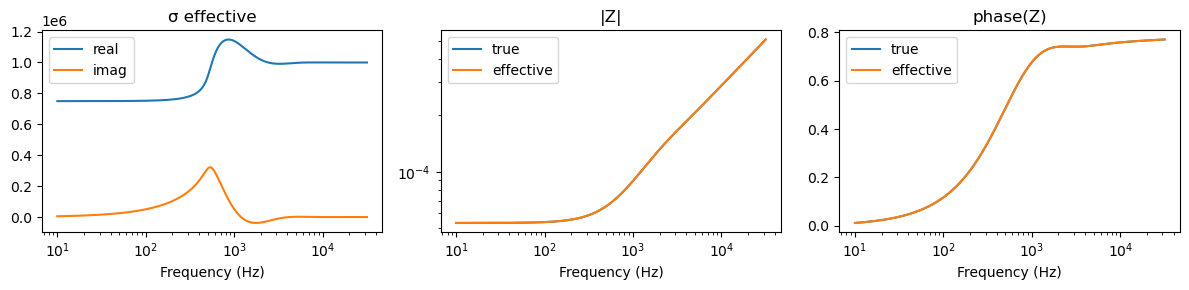

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].semilogx(frequencies, sigma_eff_casing.real, label='real')
ax[0].semilogx(frequencies, sigma_eff_casing.imag, label='imag')
ax[0].set_title('σ effective'); ax[0].legend(); ax[0].set_xlabel('Frequency (Hz)')

ax[1].loglog(frequencies, np.abs(z_casing_hollow), label='true')
ax[1].loglog(frequencies, np.abs(z_eff_casing),    label='effective')
ax[1].set_title('|Z|'); ax[1].legend(); ax[1].set_xlabel('Frequency (Hz)')

ax[2].semilogx(frequencies, np.angle(z_casing_hollow), label='true')
ax[2].semilogx(frequencies, np.angle(z_eff_casing),    label='effective')
ax[2].set_title('phase(Z)'); ax[2].legend(); ax[2].set_xlabel('Frequency (Hz)')

plt.tight_layout()

### 5a. Loss Surface (Cylinder)

In [30]:
n_real_c = n_imag_c = 50
sr_c  = np.logspace(5.5, 7.5, n_real_c)
si_c  = np.linspace(-5e6, 5e6, n_imag_c)
SR_c, SI_c = np.meshgrid(sr_c, si_c, indexing='xy')
loss_landscape_cyl = np.zeros((n_real_c, n_imag_c, len(omegas)))

for i, omega in enumerate(omegas):
    loss_landscape_cyl[:, :, i] = loss_cylinder(
        omega, b_casing, mu_casing, z_casing_hollow[i], SR_c, SI_c
    )

In [31]:
def plot_loss_cyl(index=0):
    fig, ax = plt.subplots(1, 1)
    plt.colorbar(ax.contourf(np.log10(sr_c), si_c,
                              np.log10(loss_landscape_cyl[:, :, index]), 100))
    ax.set_xlabel('log10(sigma_r)')
    ax.set_ylabel('sigma_i')
    ax.set_title(f'{frequencies[index]:1.2e} Hz')
    ax.plot(np.log10(sigma_casing), 0, 'wx', label='true')
    ax.plot(np.log10(sigma_casing * (b_casing**2 - a_casing**2) / b_casing**2), 0, 'w+', label='scaled')
    ax.legend()

ipywidgets.interact(
    plot_loss_cyl,
    index=ipywidgets.IntSlider(min=0, max=len(omegas) - 1, value=0)
)

interactive(children=(IntSlider(value=0, description='index', max=4999), Output()), _dom_classes=('widget-inte…

<function __main__.plot_loss_cyl(index=0)>

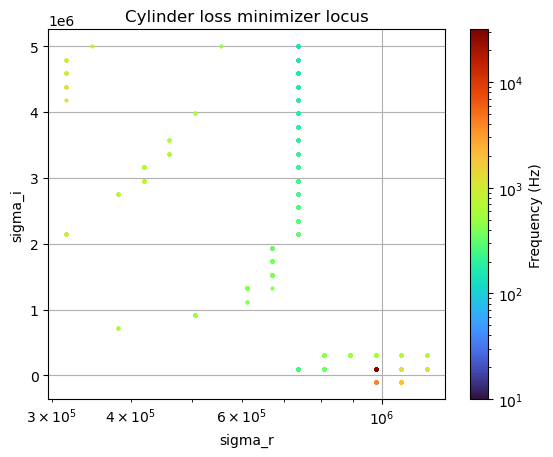

In [32]:
# Plot minimizer locus
inds_c = loss_landscape_cyl.copy()
for i in range(len(omegas)):
    thresh = loss_landscape_cyl[:, :, i].min()
    inds_c[:, :, i] = loss_landscape_cyl[:, :, i] <= thresh
inds_c = inds_c.astype(bool)

cmap = plt.cm.turbo
norm = mpl.colors.LogNorm(vmin=frequencies.min(), vmax=frequencies.max())

fig, ax = plt.subplots(1, 1)
for i, freq in enumerate(frequencies):
    ax.semilogx(SR_c[inds_c[:, :, i]], SI_c[inds_c[:, :, i]], '.', color=cmap(norm(freq)), ms=4)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax).set_label('Frequency (Hz)')
ax.set_xlabel('sigma_r'); ax.set_ylabel('sigma_i')
ax.set_title('Cylinder loss minimizer locus')
ax.grid()

## 6. Joint σ + μ Upscaling for a Cylindrical Casing

Jointly invert for effective conductivity and permeability for the solid-cylinder model.

In [33]:
k = 50
sigma_hat_cm, mu_hat_cm, z_pred_cm, ok_cm, msg_cm = solve_sigma_mu_eff_one_freq_solid_cyl(
    omegas[k], z_casing_hollow[k], b=b_casing,
    sigma0=5e6 + 0j,
    mu0=mu_0 + 0j,
    test=True,
)
print(ok_cm, sigma_hat_cm, mu_hat_cm)

==================== check_derivative ====================
iter    h         |ft-f0|   |ft-f0-h*J0*dx|  Order
---------------------------------------------------------
 0   1.00e-01    7.168e-06     2.224e-06      nan
 1   1.00e-02    7.627e-07     2.422e-08      1.963
 2   1.00e-03    7.611e-08     2.417e-10      2.001
 3   1.00e-04    7.609e-09     2.416e-12      2.000
 4   1.00e-05    7.609e-10     2.416e-14      2.000
 5   1.00e-06    7.609e-11     2.416e-16      2.000
 6   1.00e-07    7.609e-12     2.415e-18      2.000
========================= PASS! =========================
Happy little convergence test!

True (927981.5939306534+14202.724444958587j) (1.8609108596392259e-06-1.2997156313285342e-05j)


In [34]:
sigma_eff3, mu_eff3, z_fit3, ok3 = invert_sigma_mu_eff_vs_freq_solid_cyl(
    omegas, z_casing_hollow, b=b_casing,
    sigma_init=sigma_casing * (b_casing**2 - a_casing**2) / b_casing**2 + 0j,
    mu_init=0.5 * mu_0 + 0j,
    complex_values=False,
)

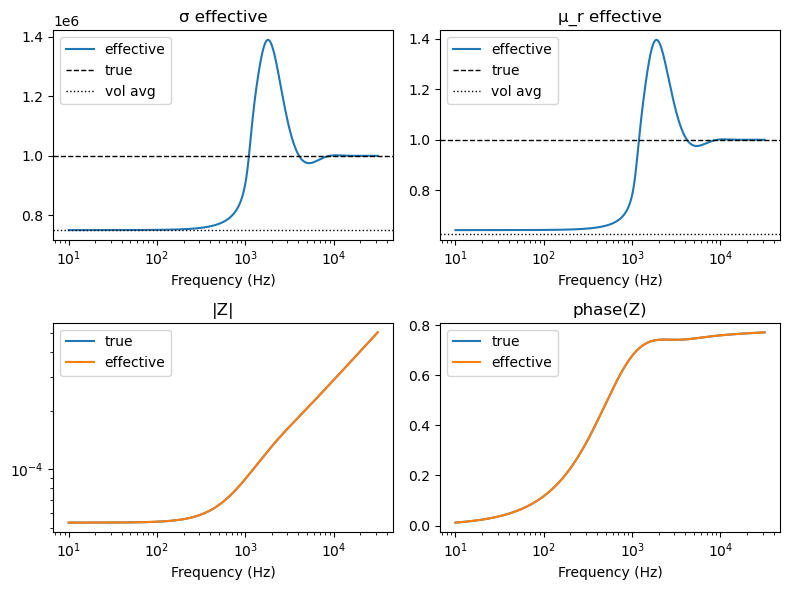

In [35]:
# Analytic volume-averaged estimates for reference
sigma_vol = sigma_casing * (b_casing**2 - a_casing**2) / b_casing**2
mur_vol   = mur_casing * (t_casing / (2 * b_casing)) * (3 - t_casing / b_casing)

fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].semilogx(frequencies, sigma_eff3.real, label='effective')
ax[0, 0].axhline(sigma_casing, ls='--', color='k', lw=1, label='true')
ax[0, 0].axhline(sigma_vol,    ls=':',  color='k', lw=1, label='vol avg')
ax[0, 0].set_title('σ effective'); ax[0, 0].legend(); ax[0, 0].set_xlabel('Frequency (Hz)')

ax[0, 1].semilogx(frequencies, mu_eff3.real / mu_0, label='effective')
ax[0, 1].axhline(mur_casing, ls='--', color='k', lw=1, label='true')
ax[0, 1].axhline(mur_vol,    ls=':',  color='k', lw=1, label='vol avg')
ax[0, 1].set_title('μ_r effective'); ax[0, 1].legend(); ax[0, 1].set_xlabel('Frequency (Hz)')

ax[1, 0].loglog(frequencies, np.abs(z_casing_hollow), label='true')
ax[1, 0].loglog(frequencies, np.abs(z_fit3),          label='effective')
ax[1, 0].set_title('|Z|'); ax[1, 0].legend(); ax[1, 0].set_xlabel('Frequency (Hz)')

ax[1, 1].semilogx(frequencies, np.angle(z_casing_hollow), label='true')
ax[1, 1].semilogx(frequencies, np.angle(z_fit3),          label='effective')
ax[1, 1].set_title('phase(Z)'); ax[1, 1].legend(); ax[1, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout()

In [36]:
sigma_eff4, mu_eff4, z_fit4, ok4 = invert_sigma_mu_eff_vs_freq_solid_cyl(
    omegas, z_casing_hollow, b=b_casing,
    sigma_init=sigma_casing * (b_casing**2 - a_casing**2) / b_casing**2 + 0j,
    mu_init=1 * mu_0 + 0j,
    complex_values=True,
)

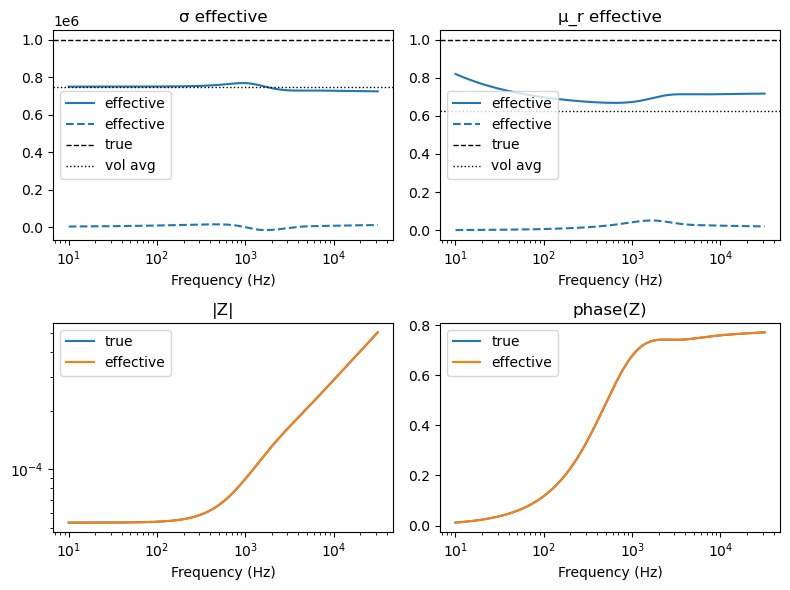

In [37]:
# Analytic volume-averaged estimates for reference
sigma_vol = sigma_casing * (b_casing**2 - a_casing**2) / b_casing**2
mur_vol   = mur_casing * (t_casing / (2 * b_casing)) * (3 - t_casing / b_casing)

fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].semilogx(frequencies, sigma_eff4.real, label='effective')
ax[0, 0].semilogx(frequencies, sigma_eff4.imag, color="C0", ls="--", label='effective')
ax[0, 0].axhline(sigma_casing, ls='--', color='k', lw=1, label='true')
ax[0, 0].axhline(sigma_vol,    ls=':',  color='k', lw=1, label='vol avg')
ax[0, 0].set_title('σ effective'); ax[0, 0].legend(); ax[0, 0].set_xlabel('Frequency (Hz)')

ax[0, 1].semilogx(frequencies, mu_eff4.real / mu_0, label='effective')
ax[0, 1].semilogx(frequencies, mu_eff4.imag / mu_0, color="C0", ls="--", label='effective')

ax[0, 1].axhline(mur_casing, ls='--', color='k', lw=1, label='true')
ax[0, 1].axhline(mur_vol,    ls=':',  color='k', lw=1, label='vol avg')
ax[0, 1].set_title('μ_r effective'); ax[0, 1].legend(); ax[0, 1].set_xlabel('Frequency (Hz)')

ax[1, 0].loglog(frequencies, np.abs(z_casing_hollow), label='true')
ax[1, 0].loglog(frequencies, np.abs(z_fit4),          label='effective')
ax[1, 0].set_title('|Z|'); ax[1, 0].legend(); ax[1, 0].set_xlabel('Frequency (Hz)')

ax[1, 1].semilogx(frequencies, np.angle(z_casing_hollow), label='true')
ax[1, 1].semilogx(frequencies, np.angle(z_fit4),          label='effective')
ax[1, 1].set_title('phase(Z)'); ax[1, 1].legend(); ax[1, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout()

### 6a. Loss Surface in (σ, μ_r) Space

In [38]:
n_r = n_m = 100
sr_m  = np.logspace(5.5, 6.5, n_r)
mur_m = np.linspace(0.1, 2, n_m)
SR_m, MUR_m = np.meshgrid(sr_m, mur_m, indexing='xy')
loss_landscape_mu = np.zeros((n_r, n_m, len(omegas)))

for i, omega in enumerate(omegas):
    loss_landscape_mu[:, :, i] = loss_cylinder(
        omega, b_casing, MUR_m * mu_0, z_casing_hollow[i], SR_m, 0
    )

In [ ]:
def plot_loss_cyl_mu(index=0):
    fig, ax = plt.subplots(1, 1)
    plt.colorbar(ax.contourf(np.log10(sr_m), mur_m,
                              np.log10(loss_landscape_mu[:, :, index]), 100))
    ax.set_xlabel('log10(sigma)'); ax.set_ylabel('mu_r')
    ax.set_title(f'{frequencies[index]:1.2e} Hz')
    ax.plot(np.log10(sigma_casing), mur_casing, 'wx', label='true')
    ax.plot(np.log10(sigma_vol), mur_vol, 'w+', label='vol avg')
    ax.legend()

ipywidgets.interact(
    plot_loss_cyl_mu,
    index=ipywidgets.IntSlider(min=0, max=len(omegas) - 1, value=0)
)

interactive(children=(IntSlider(value=0, description='index', max=4999), Output()), _dom_classes=('widget-inte…

<function __main__.plot_loss_cyl_mu(index=0)>

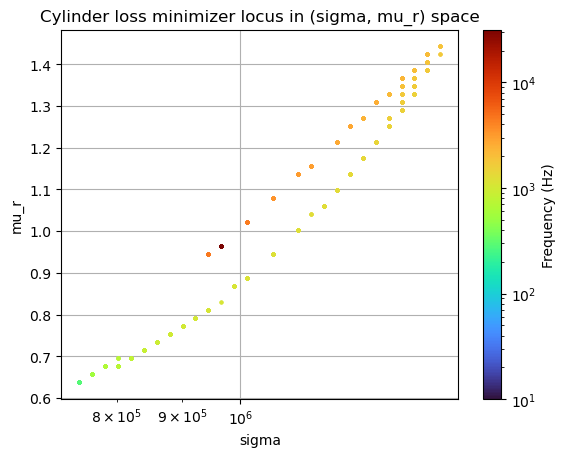

In [40]:
# Plot minimizer locus in (σ, μ_r) space
inds_m = loss_landscape_mu.copy()
for i in range(len(omegas)):
    thresh = loss_landscape_mu[:, :, i].min()
    inds_m[:, :, i] = loss_landscape_mu[:, :, i] <= thresh
inds_m = inds_m.astype(bool)

cmap = plt.cm.turbo
norm = mpl.colors.LogNorm(vmin=frequencies.min(), vmax=frequencies.max())

fig, ax = plt.subplots(1, 1)
for i, freq in enumerate(frequencies):
    ax.semilogx(SR_m[inds_m[:, :, i]], MUR_m[inds_m[:, :, i]], '.', color=cmap(norm(freq)), ms=4)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax).set_label('Frequency (Hz)')
ax.set_xlabel('sigma'); ax.set_ylabel('mu_r')
ax.set_title('Cylinder loss minimizer locus in (sigma, mu_r) space')
ax.grid()

## 7. Effect of Interior Conductivity on the Effective-Property Overshoot

The hollow casing sits inside a formation whose conductivity σ_interior can vary.
As σ_interior increases, the boundary condition seen by the casing changes and the
effective properties (σ_eff, μ_r_eff) of the upscaled solid-cylinder model shift.
The cells below sweep σ_interior and overlay the resulting curves.

In [ ]:
# Fixed casing geometry and material
b_sweep   = 0.05
t_sweep   = 0.025
a_sweep   = b_sweep - t_sweep
sigma_cas = 1e6        # S/m  – casing conductivity (fixed)
mur_cas   = 1
mu_cas    = mur_cas * mu_0

# Analytic volume-average references (depend only on geometry)
sigma_vol_frac = (b_sweep**2 - a_sweep**2) / b_sweep**2
mur_vol_frac   = (t_sweep / (2*b_sweep)) * (3 - t_sweep/b_sweep)

# Interior (bore) conductivity values to sweep (S/m)
sigma_interior_values = np.array([1e2, 1e4, 1e6])

cmap_sweep = plt.cm.viridis
norm_sweep = mpl.colors.LogNorm(
    vmin=sigma_interior_values.min(), vmax=sigma_interior_values.max()
)

results = []
for sigma_int in sigma_interior_values:
    # impedance_hollow_cyl correctly loads the bore (r < a) with sigma_int.
    # (impedance_cyl_symmetric cannot be used here: its formula has eta1*g1 = iωμ,
    #  so g1 cancels and the result is independent of sigma_bore.)
    z_hollow = impedance_hollow_cyl(
        omegas, a_sweep, b_sweep,
        mu_0, sigma_int,   # bore medium     ← swept
        mu_cas, sigma_cas  # casing material ← fixed
    )
    sig_eff, mu_eff, z_fit, ok = invert_sigma_mu_eff_vs_freq_solid_cyl(
        omegas, z_hollow, b=b_sweep,
        sigma_init=sigma_cas * sigma_vol_frac + 0j,
        mu_init=0.5 * mu_0 + 0j,
        complex_values=False,
    )
    results.append(dict(
        sigma_int=sigma_int, z_hollow=z_hollow,
        sig_eff=sig_eff, mu_eff=mu_eff, z_fit=z_fit, ok=ok
    ))
    print(f"sigma_interior = {sigma_int:.1e} S/m  |  convergence: {ok.mean()*100:.0f}%")

sigma_interior = 1.0e-06 S/m  |  convergence: 100%
sigma_interior = 1.0e-03 S/m  |  convergence: 100%
sigma_interior = 1.0e-01 S/m  |  convergence: 100%
sigma_interior = 1.0e+00 S/m  |  convergence: 100%
sigma_interior = 1.0e+01 S/m  |  convergence: 100%
sigma_interior = 1.0e+02 S/m  |  convergence: 100%


/var/folders/sl/j1q3fxbx71q7r5kh4vv1r1rm0000gn/T/ipykernel_70280/747855322.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


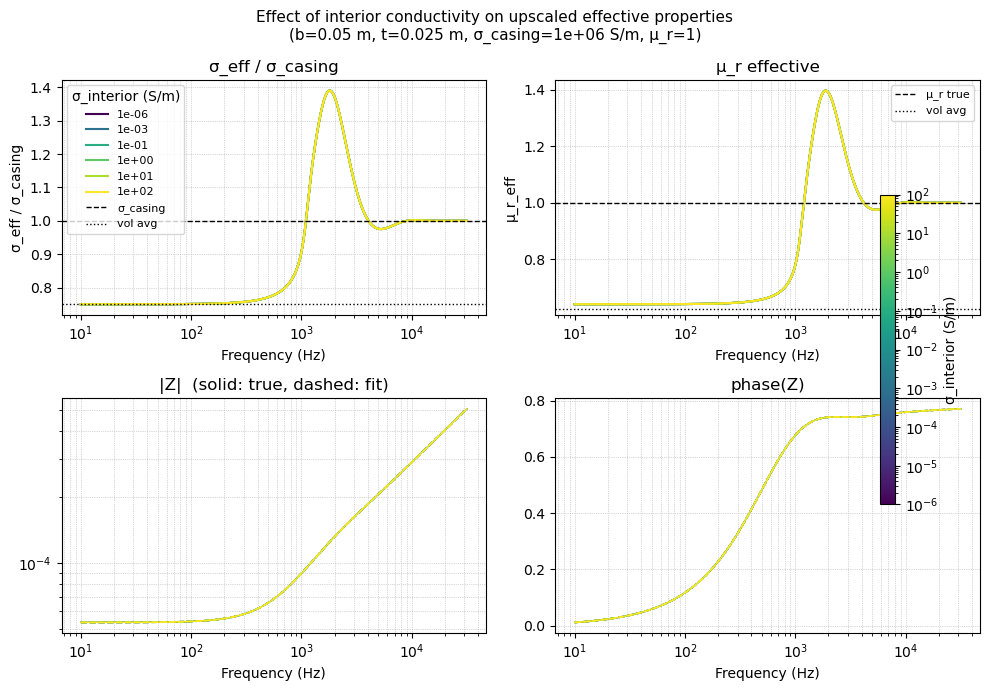

In [43]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for r in results:
    sigma_int = r['sigma_int']
    color     = cmap_sweep(norm_sweep(sigma_int))
    ok        = r['ok']

    # σ_eff normalised by σ_casing
    ax[0, 0].semilogx(
        frequencies[ok], r['sig_eff'][ok].real / sigma_cas,
        color=color, label=f"{sigma_int:.0e}"
    )

    # μ_r effective
    ax[0, 1].semilogx(
        frequencies[ok], r['mu_eff'][ok].real / mu_0,
        color=color
    )

    # |Z|
    ax[1, 0].loglog(frequencies, np.abs(r['z_hollow']), color=color, lw=0.8)
    ax[1, 0].loglog(frequencies[ok], np.abs(r['z_fit'][ok]),
                    color=color, ls='--', lw=1.2)

    # phase(Z)
    ax[1, 1].semilogx(frequencies, np.angle(r['z_hollow']), color=color, lw=0.8)
    ax[1, 1].semilogx(frequencies[ok], np.angle(r['z_fit'][ok]),
                      color=color, ls='--', lw=1.2)

# Reference lines (geometry-only)
ax[0, 0].axhline(1,              ls='--', color='k', lw=1, label='σ_casing')
ax[0, 0].axhline(sigma_vol_frac, ls=':',  color='k', lw=1, label='vol avg')
ax[0, 1].axhline(mur_cas,        ls='--', color='k', lw=1, label='μ_r true')
ax[0, 1].axhline(mur_vol_frac,   ls=':',  color='k', lw=1, label='vol avg')

ax[0, 0].set_title('σ_eff / σ_casing'); ax[0, 0].set_xlabel('Frequency (Hz)')
ax[0, 0].set_ylabel('σ_eff / σ_casing')
ax[0, 1].set_title('μ_r effective');    ax[0, 1].set_xlabel('Frequency (Hz)')
ax[0, 1].set_ylabel('μ_r_eff')
ax[1, 0].set_title('|Z|  (solid: true, dashed: fit)'); ax[1, 0].set_xlabel('Frequency (Hz)')
ax[1, 1].set_title('phase(Z)');         ax[1, 1].set_xlabel('Frequency (Hz)')

for a_ in ax.flat:
    a_.grid(True, which='both', ls=':', lw=0.5)

ax[0, 0].legend(title='σ_interior (S/m)', fontsize=8)
ax[0, 1].legend(fontsize=8)

sm = mpl.cm.ScalarMappable(norm=norm_sweep, cmap=cmap_sweep)
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('σ_interior (S/m)')

fig.suptitle(
    f'Effect of interior conductivity on upscaled effective properties\n'
    f'(b={b_sweep} m, t={t_sweep} m, σ_casing={sigma_cas:.0e} S/m, μ_r={mur_cas})',
    fontsize=11
)
plt.tight_layout()
plt.show()